# Best ML Model — CatBoost / LightGBM Multiclass + Recall Optimization (Next 3 Hours)

**Goal:** Train a stronger multiclass model than Logistic Regression for forecasting the **next 3-hour block** collision risk class (0 / 1 / 2+), and apply **recall-focused threshold tuning** for the **High-risk class (Class 2)**.

**Input:** `processed_data/supervised_hood_3h_multiclass.csv`  
**Outputs (saved to `models/`):**
- `best_ml_model.joblib` (LightGBM) **or** `best_ml_catboost.cbm` (CatBoost)
- `best_ml_features.txt`
- `best_ml_tau.txt`
- `best_ml_summary.csv`


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, average_precision_score, mean_squared_error
import matplotlib.pyplot as plt

import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

# Optional: if you want to reuse selected features from the previous phase
SEL_FEATURES_PATH = DATA_DIR / "logreg_selected_top25_features.txt" 

# Outputs
OUT_SUMMARY = MODEL_DIR / "best_ml_summary.csv"


In [10]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h", "HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))


Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [11]:
# --- Time-based split (same as earlier) ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

# Build X/y
y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class", "y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as a model feature (we already have time-derived features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [12]:
# --- Optionally use a selected feature list (keeps training faster & more interpretable) ---
use_selected_features = False  # set True if you want to use the top25 list file

if use_selected_features and SEL_FEATURES_PATH.exists():
    with open(SEL_FEATURES_PATH, "r") as f:
        sel = [line.strip() for line in f if line.strip()]
    # Keep only features that exist
    sel = [c for c in sel if c in X_train.columns]
    if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in sel:
        sel.append("HOOD_158_CODE")
    X_train = X_train[sel].copy()
    X_val   = X_val[sel].copy()
    X_test  = X_test[sel].copy()
    print("Using selected features:", len(sel))
else:
    sel = list(X_train.columns)
    print("Using all features:", len(sel))

# Identify categorical columns
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))


Using all features: 47
Categorical: ['HOOD_158_CODE']
Numeric count: 46


In [13]:
# --- Evaluation helpers ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, proba=None, name="Model"):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0, 1, 2])
    rec = recall_score(y_true_arr, y_pred_arr, labels=[0, 1, 2], average=None, zero_division=0)
    macro_rec = recall_score(y_true_arr, y_pred_arr, average="macro", zero_division=0)
    rec2 = recall_score((y_true_arr == 2).astype(int), (y_pred_arr == 2).astype(int), zero_division=0)
    prec2 = precision_score((y_true_arr == 2).astype(int), (y_pred_arr == 2).astype(int), zero_division=0)
    pred2_rate = float((y_pred_arr == 2).mean())
    label_rmse = float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)))

    out = {
        "model": name,
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "macro_recall": float(macro_rec),
        "recall_high": float(rec2),
        "precision_high": float(prec2),
        "precision_2": float(prec2),
        "pred2_rate": float(pred2_rate),
        "pred_class2_rate": float(pred2_rate),
        "label_rmse": label_rmse,
    }

    ap_vals = []
    prob_rmse_vals = []
    if proba is not None:
        proba_arr = np.asarray(proba, dtype=float)
        supports = np.bincount(y_true_arr.astype(int), minlength=3).astype(float)

        for k in range(3):
            try:
                ap_k = float(average_precision_score((y_true_arr == k).astype(int), proba_arr[:, k]))
            except Exception:
                ap_k = np.nan
            out[f"ap_class{k}"] = ap_k
            ap_vals.append(ap_k)

            try:
                rmse_k = float(np.sqrt(mean_squared_error((y_true_arr == k).astype(int), proba_arr[:, k])))
            except Exception:
                rmse_k = np.nan
            out[f"prob_rmse_class{k}"] = rmse_k
            prob_rmse_vals.append(rmse_k)

        out["macro_map"] = float(np.nanmean(ap_vals))
        valid = np.array([not np.isnan(x) for x in ap_vals], dtype=bool)
        if valid.any():
            out["weighted_map"] = float(np.average(np.array(ap_vals)[valid], weights=supports[valid]))
        else:
            out["weighted_map"] = np.nan
        out["prob_rmse_macro"] = float(np.nanmean(prob_rmse_vals))
    else:
        for k in range(3):
            out[f"ap_class{k}"] = np.nan
            out[f"prob_rmse_class{k}"] = np.nan
        out["macro_map"] = np.nan
        out["weighted_map"] = np.nan
        out["prob_rmse_macro"] = np.nan

    print(f"\\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round([out["recall_0"], out["recall_1"], out["recall_2"]], 4))
    print("Macro recall:", round(out["macro_recall"], 4))
    print("Per-class AP [0,1,2]:", np.round([out["ap_class0"], out["ap_class1"], out["ap_class2"]], 4))
    print("Macro MAP:", round(out["macro_map"], 4), "| Weighted MAP:", round(out["weighted_map"], 4))
    print("Class-label RMSE:", round(out["label_rmse"], 4), "| Probability RMSE (macro):", round(out["prob_rmse_macro"], 4))
    print("High-risk recall:", round(out["recall_high"], 4), "| High-risk precision:", round(out["precision_2"], 4))
    print("Predicted class-2 rate:", round(out["pred2_rate"], 4))
    print("\\n", classification_report(y_true_arr, y_pred_arr, digits=4, zero_division=0))

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.xticks([0, 1, 2], [0, 1, 2])
    plt.yticks([0, 1, 2], [0, 1, 2])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()
    return out

def apply_two_thresholds(proba, tau1, tau2):
    """
    Decision rule:
      if P2 >= tau2 -> 2
      elif P1 >= tau1 -> 1
      else -> 0
    """
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # overwrite -> class 2 wins
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df


In [14]:
# --- Class weights (balanced) ---
# Weights help the rare class (2) get more attention.
class_counts = y_train.value_counts().sort_index()
total = class_counts.sum()
# sklearn-style "balanced": n_samples / (n_classes * count)
weights = (total / (3 * class_counts)).to_dict()
print("Class counts (train):")
print(class_counts)
print("Class weights:")
print(weights)


Class counts (train):
y_class
0    823183
1     86350
2     13187
Name: count, dtype: int64
Class weights:
{0: 0.373639073369267, 1: 3.561937849835939, 2: 23.323980688051364}


## A) CatBoost Multiclass (recommended)
CatBoost can directly use categorical features without one-hot encoding and typically performs very well on tabular data.


0:	learn: 0.6798079	test: 0.6796923	best: 0.6796923 (0)	total: 722ms	remaining: 36m 4s
200:	learn: 0.4103135	test: 0.4082223	best: 0.4082223 (200)	total: 1m 45s	remaining: 24m 31s
400:	learn: 0.4070209	test: 0.4066786	best: 0.4066786 (400)	total: 3m 40s	remaining: 23m 49s
600:	learn: 0.4048187	test: 0.4063713	best: 0.4063563 (575)	total: 5m 35s	remaining: 22m 18s
800:	learn: 0.4027874	test: 0.4062419	best: 0.4062419 (800)	total: 7m 37s	remaining: 20m 55s
1000:	learn: 0.4009752	test: 0.4062719	best: 0.4062196 (816)	total: 9m 53s	remaining: 19m 45s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.4062196027
bestIteration = 816

Shrink model to first 817 iterations.
\n=== CatBoost Argmax - Val ===
Per-class recall [0,1,2]: [0.9583 0.1367 0.153 ]
Macro recall: 0.416
Per-class AP [0,1,2]: [0.9616 0.196  0.1089]
Macro MAP: 0.4222 | Weighted MAP: 0.8801
Class-label RMSE: 0.4121 | Probability RMSE (macro): 0.2601
High-risk recall: 0.153 | High-risk precision: 0.1773
Predict

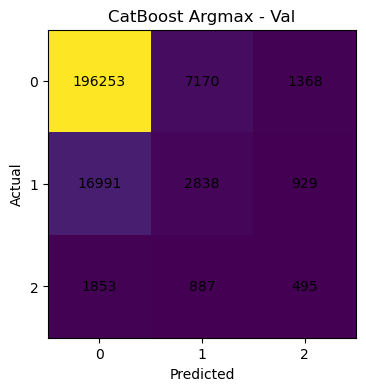

\n=== CatBoost Argmax - Test ===
Per-class recall [0,1,2]: [0.9488 0.1581 0.2014]
Macro recall: 0.4361
Per-class AP [0,1,2]: [0.9622 0.1996 0.1233]
Macro MAP: 0.4284 | Weighted MAP: 0.8804
Class-label RMSE: 0.4279 | Probability RMSE (macro): 0.2652
High-risk recall: 0.2014 | High-risk precision: 0.1738
Predicted class-2 rate: 0.017
\n               precision    recall  f1-score   support

           0     0.9148    0.9488    0.9315    207818
           1     0.2592    0.1581    0.1964     21189
           2     0.1738    0.2014    0.1866      3411

    accuracy                         0.8658    232418
   macro avg     0.4493    0.4361    0.4382    232418
weighted avg     0.8442    0.8658    0.8536    232418



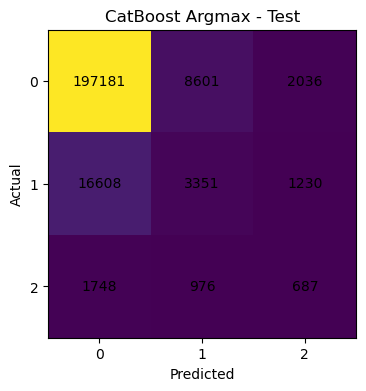

Chosen thresholds (CatBoost): {'tau1': 0.25, 'tau2': 0.125}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
18,0.25,0.125,0.545032,0.307785,0.629057,0.064887,0.137081
3,0.20,0.125,0.545003,0.433231,0.629057,0.064887,0.137081
17,0.25,0.100,0.542405,0.232970,0.696754,0.055091,0.178832
2,0.20,0.100,0.542267,0.357356,0.696754,0.055091,0.178832
4,0.20,0.150,0.541152,0.492148,0.558578,0.074225,0.106410
19,0.25,0.150,0.541135,0.366365,0.558578,0.074225,0.106410
5,0.20,0.175,0.540550,0.544128,0.504791,0.085034,0.083939
20,0.25,0.175,0.540458,0.418056,0.504791,0.085034,0.083939
6,0.20,0.200,0.536258,0.580403,0.455641,0.094748,0.067999
21,0.25,0.200,0.536115,0.454138,0.455641,0.094748,0.067999


\n=== CatBoost Two-Threshold (tau1=0.25, tau2=0.12) - Test ===
Per-class recall [0,1,2]: [0.6726 0.3022 0.6752]
Macro recall: 0.55
Per-class AP [0,1,2]: [0.9622 0.1996 0.1233]
Macro MAP: 0.4284 | Weighted MAP: 0.8804
Class-label RMSE: 0.8293 | Probability RMSE (macro): 0.2652
High-risk recall: 0.6752 | High-risk precision: 0.065
Predicted class-2 rate: 0.1523
\n               precision    recall  f1-score   support

           0     0.9524    0.6726    0.7884    207818
           1     0.1274    0.3022    0.1793     21189
           2     0.0650    0.6752    0.1187      3411

    accuracy                         0.6389    232418
   macro avg     0.3816    0.5500    0.3621    232418
weighted avg     0.8642    0.6389    0.7231    232418



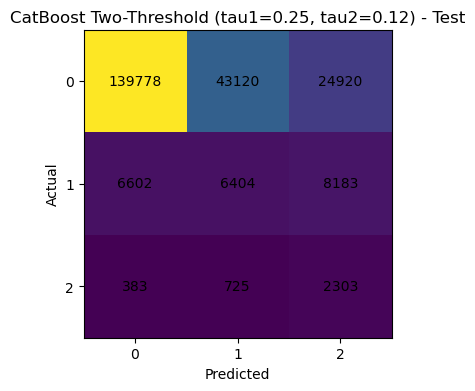

Saved: ../models/best_ml_catboost.cbm
Saved: ../models/best_ml_catboost_thresholds.json
Saved: ../models/best_ml_catboost_features.txt


In [16]:
# --- CatBoost training ---
import json

try:
    from catboost import CatBoostClassifier
    catboost_available = True
except Exception as e:
    catboost_available = False
    print("CatBoost not available:", e)

results = []

if catboost_available:
    # Identify categorical feature indices for CatBoost
    cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

    cb = CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=10.0,
        random_seed=42,
        verbose=200,
        auto_class_weights="SqrtBalanced",
        od_type="Iter",
        od_wait=300
    )

    cb.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    # Probabilities first
    proba_val_cb = cb.predict_proba(X_val)
    proba_test_cb = cb.predict_proba(X_test)

    # Argmax evaluation
    pred_val_cb = np.argmax(proba_val_cb, axis=1).astype(int)
    metrics_val = eval_multiclass(y_val, pred_val_cb, proba_val_cb, name="CatBoost Argmax - Val")

    pred_test_cb = np.argmax(proba_test_cb, axis=1).astype(int)
    metrics_test = eval_multiclass(y_test, pred_test_cb, proba_test_cb, name="CatBoost Argmax - Test")

    # Two-threshold tuning on validation -> apply to test
    tau1_cb, tau2_cb, grid_cb = tune_two_thresholds(
        proba_val_cb, y_val,
        min_recall_1=0.25,
        max_pred2_rate=0.15
    )
    print("Chosen thresholds (CatBoost):", {"tau1": tau1_cb, "tau2": tau2_cb})
    display(grid_cb.sort_values(["macro_recall", "recall_2", "precision_2"], ascending=False).head(10))

    pred_test_cb_thr = apply_two_thresholds(proba_test_cb, tau1_cb, tau2_cb)
    metrics_test_thr = eval_multiclass(
        y_test,
        pred_test_cb_thr,
        proba_test_cb,
        name=f"CatBoost Two-Threshold (tau1={tau1_cb:.2f}, tau2={tau2_cb:.2f}) - Test"
    )

    # Save CatBoost model
    OUT_CB = MODEL_DIR / "best_ml_catboost.cbm"
    cb.save_model(str(OUT_CB))

    # Save tau + features
    OUT_CB_THR = MODEL_DIR / "best_ml_catboost_thresholds.json"
    with open(OUT_CB_THR, "w") as f:
        json.dump({"tau1": float(tau1_cb), "tau2": float(tau2_cb)}, f, indent=2)

    OUT_CB_FEATS = MODEL_DIR / "best_ml_catboost_features.txt"
    with open(OUT_CB_FEATS, "w") as f:
        for c in X_train.columns:
            f.write(c + "\n")

    results.append({
        "model": "CatBoost Argmax",
        **metrics_test
    })
    results.append({
        "model": f"CatBoost Two-Threshold (tau1={tau1_cb:.2f}, tau2={tau2_cb:.2f})",
        **metrics_test_thr
    })

    print("Saved:", OUT_CB)
    print("Saved:", OUT_CB_THR)
    print("Saved:", OUT_CB_FEATS)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# identify columns
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## B) LightGBM Multiclass (optional alternative)

LightGBM usually needs categorical features encoded. We use one-hot encoding via a preprocessing pipeline.  
No scaling is required for tree models, but keeping numeric imputation is important.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2806
[LightGBM] [Info] Number of data points in the train set: 922720, number of used features: 204
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
\n=== LightGBM Argmax - Val ===
Per-class recall [0,1,2]: [0.6727 0.4633 0.4198]
Macro recall: 0.5186
Per-class AP [0,1,2]: [0.9614 0.1402 0.0905]
Macro MAP: 0.3974 | Weighted MAP: 0.8746
Class-label RMSE: 0.7253 | Probability RMSE (macro): 0.3659
High-risk recall: 0.4198 | High-risk precision: 0.0723
Predicted class-2 rate: 0.0821
\n               precision    recall  f1-score   support

           0     0.9506    0.6727    0.7879    204791
           1     0.1478    0.4633    

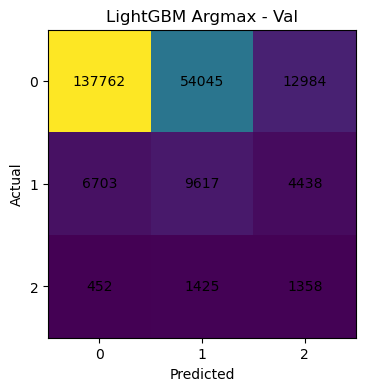

\n=== LightGBM Argmax - Test ===
Per-class recall [0,1,2]: [0.6513 0.4582 0.4975]
Macro recall: 0.5357
Per-class AP [0,1,2]: [0.9621 0.1354 0.111 ]
Macro MAP: 0.4028 | Weighted MAP: 0.8742
Class-label RMSE: 0.7536 | Probability RMSE (macro): 0.3727
High-risk recall: 0.4975 | High-risk precision: 0.0769
Predicted class-2 rate: 0.0949
\n               precision    recall  f1-score   support

           0     0.9538    0.6513    0.7740    207818
           1     0.1418    0.4582    0.2166     21189
           2     0.0769    0.4975    0.1332      3411

    accuracy                         0.6314    232418
   macro avg     0.3908    0.5357    0.3746    232418
weighted avg     0.8669    0.6314    0.7138    232418



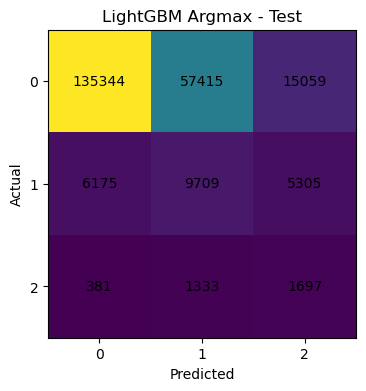

Chosen thresholds (LightGBM): {'tau1': 0.4, 'tau2': 0.325}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
69,0.40,0.275,0.529884,0.277194,0.697372,0.048777,0.202160
70,0.40,0.300,0.529792,0.315300,0.649150,0.053614,0.171205
68,0.40,0.250,0.528509,0.238029,0.744049,0.044408,0.236913
71,0.40,0.325,0.528065,0.350756,0.600618,0.058943,0.144084
83,0.45,0.250,0.526975,0.144282,0.744049,0.044408,0.236913
55,0.35,0.300,0.526723,0.418586,0.649150,0.053614,0.171205
56,0.35,0.325,0.526523,0.463869,0.600618,0.058943,0.144084
72,0.40,0.350,0.525873,0.382359,0.555487,0.064645,0.121503
54,0.35,0.275,0.525775,0.370700,0.697372,0.048777,0.202160
84,0.45,0.275,0.525772,0.164804,0.697372,0.048777,0.202160


\n=== LightGBM Two-Threshold (tau1=0.40, tau2=0.33) - Test ===
Per-class recall [0,1,2]: [0.6144 0.3336 0.6734]
Macro recall: 0.5405
Per-class AP [0,1,2]: [0.9621 0.1354 0.111 ]
Macro MAP: 0.4028 | Weighted MAP: 0.8742
Class-label RMSE: 0.8768 | Probability RMSE (macro): 0.3727
High-risk recall: 0.6734 | High-risk precision: 0.0604
Predicted class-2 rate: 0.1635
\n               precision    recall  f1-score   support

           0     0.9538    0.6144    0.7474    207818
           1     0.1167    0.3336    0.1729     21189
           2     0.0604    0.6734    0.1109      3411

    accuracy                         0.5897    232418
   macro avg     0.3770    0.5405    0.3438    232418
weighted avg     0.8644    0.5897    0.6857    232418



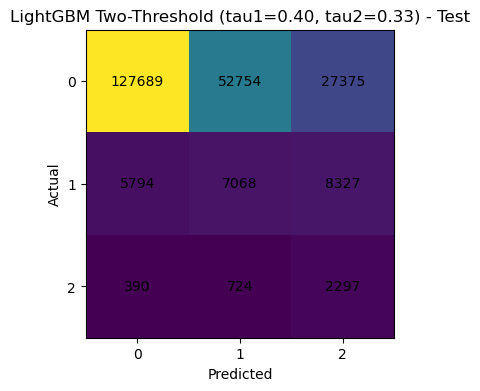

Saved: ../models/best_ml_lightgbm.pkl
Saved: ../models/best_ml_lightgbm_thresholds.json
Saved: ../models/best_ml_lightgbm_features.txt


In [20]:
# --- LightGBM training ---
import json

try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
except Exception as e:
    lightgbm_available = False
    print("LightGBM not available:", e)

if lightgbm_available:
    lgbm = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight="balanced"
    )

    lgbm_pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", lgbm)
    ])

    lgbm_pipe.fit(X_train, y_train)

    # Probabilities first
    proba_val_lgbm = lgbm_pipe.predict_proba(X_val)
    proba_test_lgbm = lgbm_pipe.predict_proba(X_test)

    # Argmax evaluation
    pred_val_lgbm = np.argmax(proba_val_lgbm, axis=1).astype(int)
    metrics_val = eval_multiclass(
        y_val,
        pred_val_lgbm,
        proba_val_lgbm,
        name="LightGBM Argmax - Val"
    )

    pred_test_lgbm = np.argmax(proba_test_lgbm, axis=1).astype(int)
    metrics_test = eval_multiclass(
        y_test,
        pred_test_lgbm,
        proba_test_lgbm,
        name="LightGBM Argmax - Test"
    )

    # Two-threshold tuning on validation -> apply to test
    tau1_lgbm, tau2_lgbm, grid_lgbm = tune_two_thresholds(
        proba_val_lgbm,
        y_val,
        min_recall_1=0.25,
        max_pred2_rate=0.15
    )
    print("Chosen thresholds (LightGBM):", {"tau1": tau1_lgbm, "tau2": tau2_lgbm})
    display(grid_lgbm.sort_values(["macro_recall", "recall_2", "precision_2"], ascending=False).head(10))

    pred_test_lgbm_thr = apply_two_thresholds(proba_test_lgbm, tau1_lgbm, tau2_lgbm)
    metrics_test_thr = eval_multiclass(
        y_test,
        pred_test_lgbm_thr,
        proba_test_lgbm,
        name=f"LightGBM Two-Threshold (tau1={tau1_lgbm:.2f}, tau2={tau2_lgbm:.2f}) - Test"
    )

    # Save LightGBM model
    OUT_LGBM = MODEL_DIR / "best_ml_lightgbm.pkl"
    joblib.dump(lgbm_pipe, OUT_LGBM)

    OUT_LGBM_THR = MODEL_DIR / "best_ml_lightgbm_thresholds.json"
    with open(OUT_LGBM_THR, "w") as f:
        json.dump({"tau1": float(tau1_lgbm), "tau2": float(tau2_lgbm)}, f, indent=2)

    OUT_LGBM_FEATS = MODEL_DIR / "best_ml_lightgbm_features.txt"
    with open(OUT_LGBM_FEATS, "w") as f:
        for c in X_train.columns:
            f.write(c + "\n")

    results.append({
        "model": "LightGBM Argmax",
        **metrics_test
    })
    results.append({
        "model": f"LightGBM Two-Threshold (tau1={tau1_lgbm:.2f}, tau2={tau2_lgbm:.2f})",
        **metrics_test_thr
    })

    print("Saved:", OUT_LGBM)
    print("Saved:", OUT_LGBM_THR)
    print("Saved:", OUT_LGBM_FEATS)

In [21]:
# --- Compare models (Test metrics summary) ---
summary = pd.DataFrame(results)

if len(summary):
    # Standardize any old column names if they still exist
    rename_map = {
        "recall_high": "recall_2",
        "precision_high": "precision_2",
    }
    summary = summary.rename(columns={k: v for k, v in rename_map.items() if k in summary.columns})

    # Ensure the final comparison columns exist
    for col in ["macro_recall", "recall_2", "precision_2", "ap_class2", "macro_map", "prob_rmse_macro"]:
        if col not in summary.columns:
            summary[col] = np.nan

    summary = summary[
        [c for c in [
            "model",
            "macro_recall",
            "recall_2",
            "precision_2",
            "ap_class2",
            "macro_map",
            "prob_rmse_macro"
        ] if c in summary.columns]
    ].copy()

    summary = summary.sort_values(
        ["macro_recall", "ap_class2", "prob_rmse_macro"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    display(summary)
    summary.to_csv(OUT_SUMMARY, index=False)
    print("Saved:", OUT_SUMMARY)
else:
    print("No ML models ran (install catboost/lightgbm and rerun).")

,model,macro_recall,recall_2,recall_2,precision_2,precision_2,ap_class2,macro_map,prob_rmse_macro
0,"CatBoost Two-Threshold (tau1=0.25, tau2=0.12) ...",0.550000,0.675169,0.675169,0.065045,0.065045,0.123335,0.428370,0.265187
1,"LightGBM Two-Threshold (tau1=0.40, tau2=0.33) ...",0.540469,0.673410,0.673410,0.060449,0.060449,0.111032,0.402844,0.372717
2,LightGBM Argmax - Test,0.535660,0.497508,0.497508,0.076923,0.076923,0.111032,0.402844,0.372717
3,CatBoost Argmax - Test,0.436124,0.201407,0.201407,0.173792,0.173792,0.123335,0.428370,0.265187


Saved: ../models/best_ml_summary.csv
